In [1]:
!pip install arabic-reshaper python-bidi

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
np.set_printoptions(suppress=True)
import arabic_reshaper
from bidi.algorithm import get_display

In [3]:
dataset = pd.read_csv("dataset_clean.csv")

In [4]:
def arabic_text(text):
    if isinstance(text, str):
        reshaped = arabic_reshaper.reshape(text)
        return get_display(reshaped)
    return text

In [5]:
dataset.head()

,mainlocation,neighborhood,frontage,purpose,streetwidth,size,Pricepm,land_price
0,الرياض,حي ظهرة لبن,شمال,سكني,20.0,727,1800,1308600
1,بريدة,حي مشعل,غرب,سكني,15.0,450,950,427500
2,الخبر,حي الحمرا,غرب,تجاري,100.0,1450,3500,5075000
3,الخبر,حي الحزام الاخضر,شرق,سكني,15.0,440,2700,1188000
4,بريدة,حي الرحاب,جنوب غربي,سكني أو تجاري,40.0,784,950,744800


#Average Land Price distribution by city (Bar Chart)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


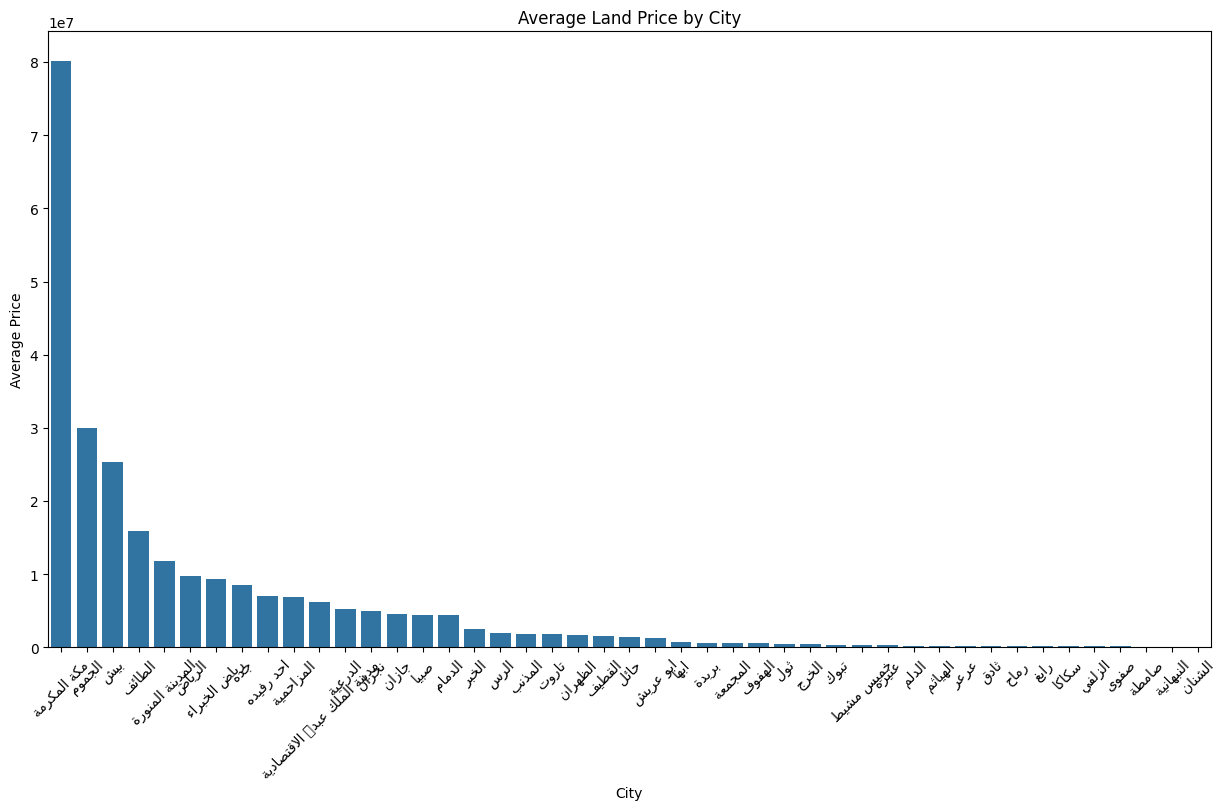

In [17]:

dataset_copy = dataset.copy()
dataset_copy['mainlocation_display'] = dataset_copy['mainlocation'].apply(arabic_text)

city_price = dataset_copy.groupby('mainlocation_display')['land_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x=city_price.index, y=city_price.values)

plt.title("Average Land Price by City")
plt.xlabel("City")
plt.ylabel("Average Price")

plt.xticks(rotation=45)
plt.show()

#Average street width distribution by purpose (Bar Chart)

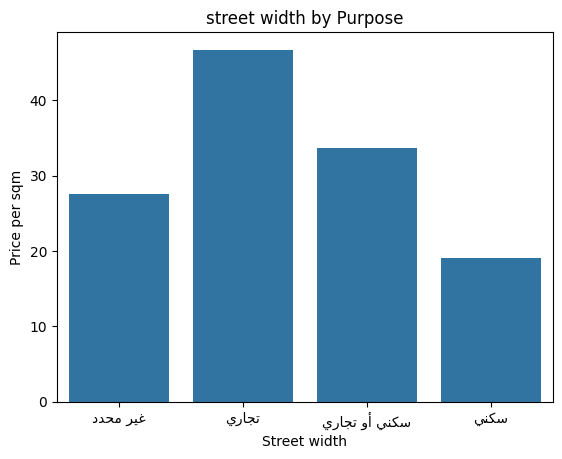

In [14]:
purpose_price = dataset_copy.groupby('purpose_display')['streetwidth'].mean()

sns.barplot(x=purpose_price.index, y=purpose_price.values)

plt.title("street width by Purpose")
plt.xlabel("Street width")
plt.ylabel("Price per sqm")
plt.show()

#Purpose Distribution

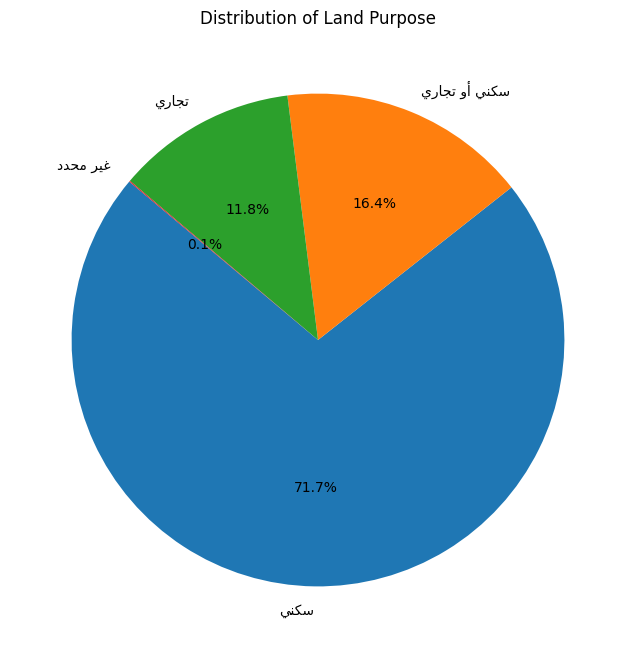

In [10]:
plt.figure(figsize=(8, 8))
purpose_counts = dataset_copy['purpose_display'].value_counts()

plt.pie(purpose_counts, labels=purpose_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Land Purpose')
plt.show()

#Relationship between Land Size and Total Price

/tmp/ipykernel_10533/1455619156.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


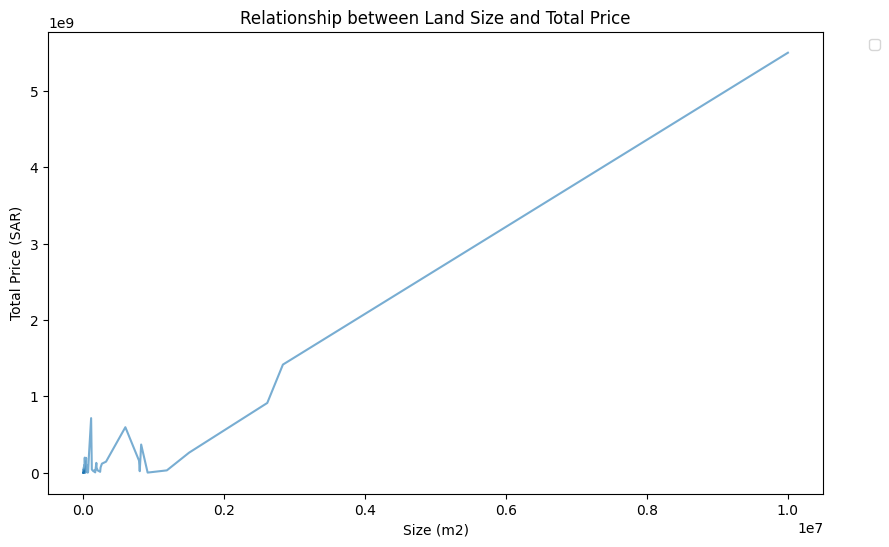

In [24]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=dataset_copy, x='size', y='land_price', alpha=0.6)
plt.title('Relationship between Land Size and Total Price')
plt.xlabel('Size (m2)')
plt.ylabel('Total Price (SAR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#Relationship between street width and Total Price

/tmp/ipykernel_10533/1663658968.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


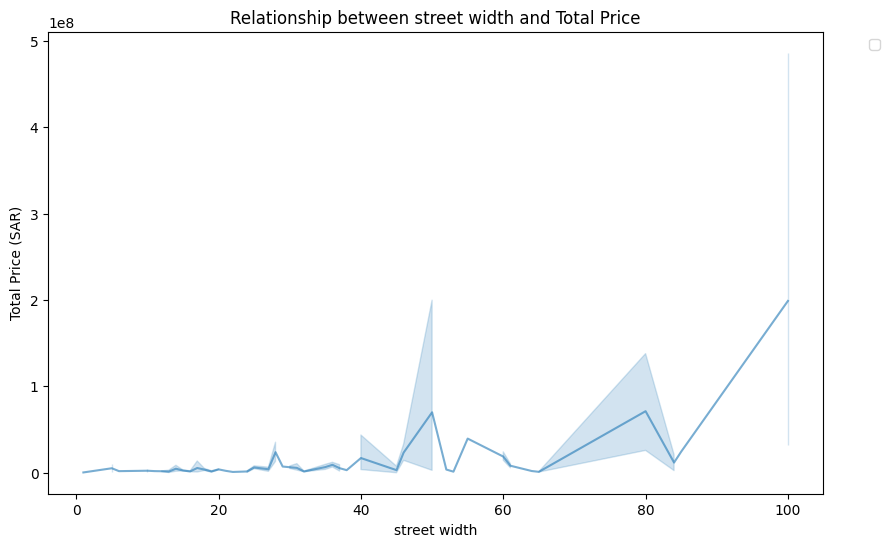

In [29]:
plt.figure(figsize=(10, 6))

#sns.scatterplot(data=dataset_copy, x='size', y='streetwidth', hue='mainlocation_display', alpha=0.6)
sns.lineplot(data=dataset_copy, x='streetwidth', y='land_price', alpha=0.6)
plt.title('Relationship between street width and Total Price')
plt.xlabel('street width')
plt.ylabel('Total Price (SAR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#Average Total Price by Frontage Type

/tmp/ipykernel_10533/473515269.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_frontage.index, y=avg_price_frontage.values, palette='magma')


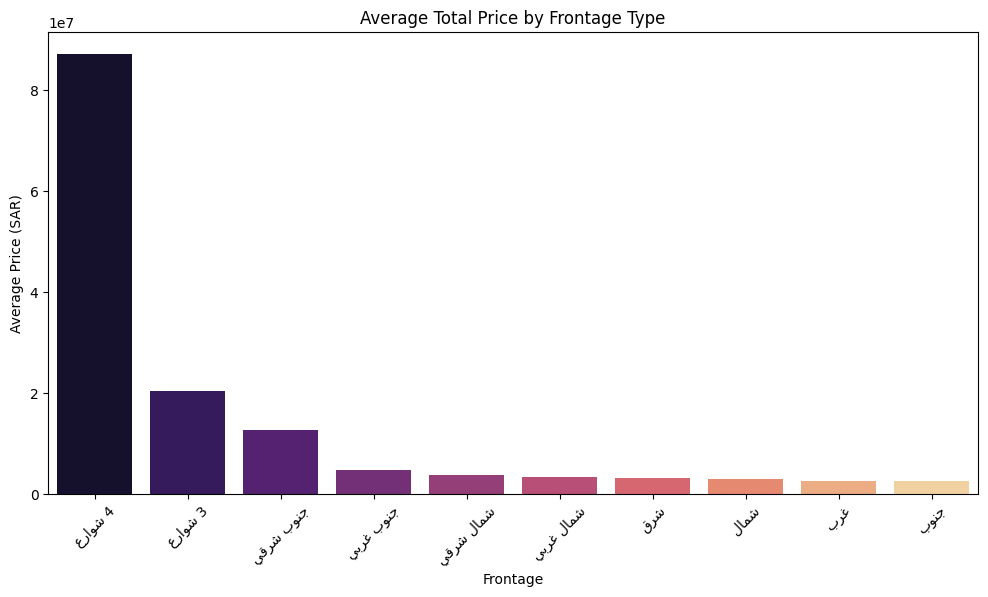

In [13]:
dataset_copy['frontage_display'] = dataset_copy['frontage'].apply(arabic_text)

plt.figure(figsize=(12, 6))
avg_price_frontage = dataset_copy.groupby('frontage_display')['land_price'].mean().sort_values(ascending=False)

sns.barplot(x=avg_price_frontage.index, y=avg_price_frontage.values, palette='magma')
plt.title('Average Total Price by Frontage Type')
plt.xlabel('Frontage')
plt.ylabel('Average Price (SAR)')
plt.xticks(rotation=45)
plt.show()